# Patrón 6: Reflection / Self-Critique

### ¿Qué es?
El patrón **Reflection** implementa un ciclo de **generación → crítica → refinamiento** que se itera hasta que la calidad supera un umbral definido. Elimina alucinaciones y mejora la calidad iterativamente.

Caso de uso:  Automated Essay Scoring + Feedback Generation usando el dataset ASAP 2.0 de Kaggle (Learning Agency Lab, ~24,000 ensayos, licencia CC BY)

El agente genera feedback → una critique evalúa si el feedback es suficientemente útil y específico → refina hasta alcanzar un score ≥ 0.8

Dependencias:
```bash
!pip install langgraph langchain langchain-anthropic \
             langchain-core kaggle pandas python-dotenv \
             --quiet
```
Dataset: Learning Agency Lab - Automated Essay Scoring 2.0
URL:     https://www.kaggle.com/competitions/learning-agency-lab-automated-essay-scoring-2/data
Licencia: CC BY (open access)
Tamaño:  ~24,000 ensayos argumentativos de estudiantes, calificados del 1 al 6

INSTRUCCIONES para obtener las credenciales de Kaggle:
   1. Ve a https://www.kaggle.com/me/account
   2. Sección "API" → "Create New API Token"
   3. Descarga el archivo kaggle.json
   4. Colócalo en ~/.kaggle/kaggle.json  (Linux/Mac)
      o en C:\Users\TU_USUARIO\.kaggle\kaggle.json  (Windows)

Diagrama Caso de Uso:

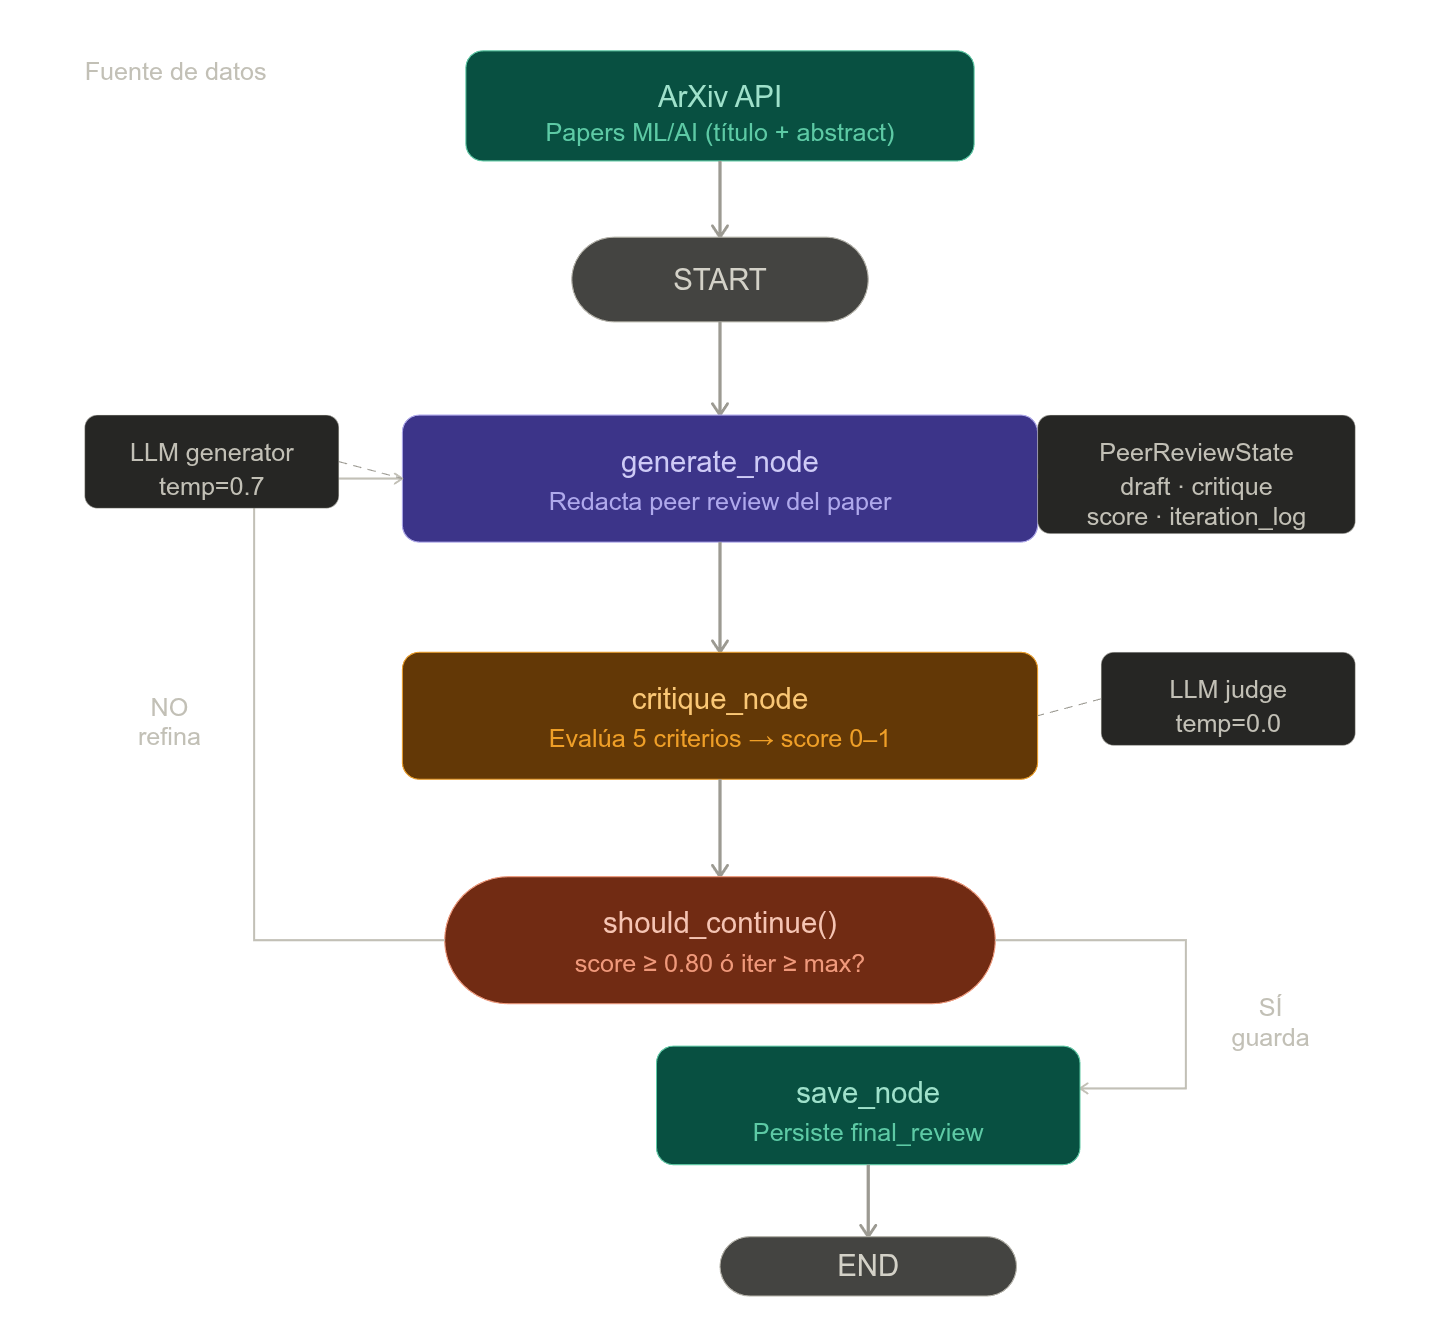

Nodos:
|Nodo/Componente|Tipo|Función|Descripción|
|:--------------|:---|:------|:----------|
|ArXiv API|Fuente de datos|Proveer input real|API REST pública de ArXiv. Retorna papers de cs.LG, cs.CL y cs.AI con título y abstract. Sin autenticación. Descarga ~130 papers en CSV cacheado localmente.|
|PeerReviewState|Estado|Transportar estado entre nodos|TypedDict compartido que fluye por todo el grafo. Contiene: paper_title, paper_abstract, draft_review, critique, quality_score, score_breakdown, iteration, max_iterations, quality_threshold, final_review e iteration_log.|
|generate_node|Nodo LangGraph|Generar borrador de peer review|Primera iteración: genera la peer review completa del paper (Resumen, Fortalezas, Debilidades, Preguntas, Recomendación). Iteraciones siguientes: incorpora la crítica recibida y refina el draft anterior. Usa LLM generator con temperature=0.7.|
|critique_node|Nodo LangGraph|Evaluar calidad del draft|Evalúa el borrador con un LLM juez en 5 criterios: especificidad, tecnicidad, constructividad, estructura y equilibrio. Devuelve un score_total de 0.0 a 1.0 en formato JSON y una crítica textual con puntos a mejorar. Usa LLM judge con temperature=0.0.|
|should_continue()|Router condicional|Decidir si refinar o guardar|Función de enrutamiento del Patrón 6. Evalúa dos condiciones: si quality_score ≥ 0.80 → ruta a save. Si iteration ≥ max_iterations → ruta a save (límite alcanzado). En cualquier otro caso → ruta de vuelta a generate para refinar.|
|save_node|Nodo LangGraph|Persistir resultado final|Copia draft_review al campo final_review del estado. Registra la razón del cierre (threshold alcanzado o máximo de iteraciones). Es el único punto de salida hacia END.|
|LLM generator|LLM|Generar texto creativo|claude-sonnet-4-20250514 con temperature=0.7. Mayor temperatura para generar reviews diversas y detalladas. Recibe el system prompt con el formato de peer review requerido.|
|LLM judge|LLM|Evaluar calidad de forma determinística|claude-sonnet-4-20250514 con temperature=0.0. Temperatura cero para evaluaciones consistentes y reproducibles. Recibe el system prompt con los 5 criterios de evaluación y retorna JSON estructurado.|
|MAX_ITERATIONS|Constante de control|Limitar ciclos de refinamiento|Valor = 3. Define el número máximo de veces que el grafo puede iterar entre generate → critique → generate antes de forzar el guardado, independientemente del score obtenido.|
|QUALITY_THRESHOLD|Constante de control|Definir umbral de calidad aceptable|Valor = 0.80. Score mínimo que debe alcanzar la review para ser aprobada por el router sin necesidad de más iteraciones. Si se supera, el grafo sale del ciclo inmediatamente.|


### Cuándo usarlo
- ✅ Generación de código con validación de calidad
- ✅ Redacción de documentos técnicos o legales
- ✅ Análisis de incidentes IT con auto-corrección
- ❌ Tasks simples donde la primera respuesta suele ser suficiente






In [1]:
!pip install langgraph langchain langchain-anthropic \
             langchain-core kaggle pandas python-dotenv grandalf \
             --quiet

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.14/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

In [2]:
from dotenv import load_dotenv
load_dotenv()

True

In [3]:
import os
import json
import pandas as pd
from typing import TypedDict
from IPython.display import display, Markdown

from langgraph.graph import StateGraph, START, END
from langchain_anthropic import ChatAnthropic




In [ ]:
# ── Patch compatibilidad: langchain-core vs paquete `langchain` ───────────────
# langchain-core consulta globals (verbose/debug/llm_cache) en el módulo `langchain`.
# Si esa versión no los expone -> AttributeError ("module 'langchain' has no
# attribute 'verbose'"). Ejecuta esta celda ANTES de instanciar ChatAnthropic.
import langchain
import langchain_core.globals as _lcg
for _attr, _default in (("verbose", False), ("debug", False), ("llm_cache", None)):
    if not hasattr(langchain, _attr):
        setattr(langchain, _attr, _default)
for _name, _fb in (("get_verbose", False), ("get_llm_cache", None)):
    _orig = getattr(_lcg, _name, None)
    if _orig is not None:
        def _make(orig, fb):
            def _patched():
                try:
                    return orig()
                except AttributeError:
                    return fb
            return _patched
        setattr(_lcg, _name, _make(_orig, _fb))
print("✅ patch compatibilidad langchain aplicado")


In [4]:
llm       = ChatAnthropic(model="claude-sonnet-4-20250514", temperature=0.7)
llm_judge = ChatAnthropic(model="claude-sonnet-4-20250514", temperature=0.0)

print("✅ LLMs configurados")
print(f"   Generator : claude-sonnet-4 (temp=0.7)")
print(f"   Critic    : claude-sonnet-4 (temp=0.0  — más determinístico)")

✅ LLMs configurados
   Generator : claude-sonnet-4 (temp=0.7)
   Critic    : claude-sonnet-4 (temp=0.0  — más determinístico)


### Descarga del Dataset

In [5]:
# Celda 3: Dataset de papers ML/AI desde ArXiv API
#
# ArXiv tiene una API REST pública, gratuita, sin token, sin cuenta.
# Descargamos papers reales de cs.LG / cs.AI / cs.CL con título y abstract.
# Estos abstracts son el INPUT del agente — generará peer reviews para ellos.
#
# API docs: https://arxiv.org/help/api
# Sin HuggingFace, sin Kaggle, sin autenticación de ningún tipo.

import requests
import xml.etree.ElementTree as ET
import pandas as pd
import time
from pathlib import Path

DATA_DIR   = Path("./data/arxiv")
DATA_DIR.mkdir(parents=True, exist_ok=True)
CACHE_FILE = DATA_DIR / "arxiv_papers.csv"

ARXIV_API  = "http://export.arxiv.org/api/query"
NS         = {"atom": "http://www.w3.org/2005/Atom"}

# Categorías y cantidad de papers a descargar
QUERIES = [
    ("cat:cs.LG", 60),   # Machine Learning
    ("cat:cs.CL", 40),   # Computation and Language (NLP)
    ("cat:cs.AI", 30),   # Artificial Intelligence
]

def fetch_arxiv(query: str, max_results: int, start: int = 0) -> list[dict]:
    """Consulta la API de ArXiv y retorna lista de papers."""
    params = {
        "search_query": query,
        "start"        : start,
        "max_results"  : max_results,
        "sortBy"       : "submittedDate",
        "sortOrder"    : "descending",
    }
    resp = requests.get(ARXIV_API, params=params, timeout=30)
    resp.raise_for_status()

    root    = ET.fromstring(resp.text)
    papers  = []

    for entry in root.findall("atom:entry", NS):
        title    = entry.findtext("atom:title",   "", NS).strip().replace("\n", " ")
        abstract = entry.findtext("atom:summary", "", NS).strip().replace("\n", " ")
        arxiv_id = entry.findtext("atom:id",      "", NS).split("/abs/")[-1]

        # Categorías del paper
        cats = [c.get("term", "") for c in entry.findall("atom:category", NS)]

        if len(abstract) < 100:
            continue

        papers.append({
            "arxiv_id": arxiv_id,
            "title"   : title[:250],
            "abstract": abstract[:1500],
            "category": cats[0] if cats else query,
        })
    return papers


# Descargar o cargar desde caché
if CACHE_FILE.exists():
    print(f"✅ Cargando desde caché: {CACHE_FILE}")
    df = pd.read_csv(CACHE_FILE)
else:
    print("⬇️  Descargando papers desde ArXiv API...")
    all_papers = []

    for query, n in QUERIES:
        print(f"   Consultando {query} ({n} papers)...", end=" ")
        papers = fetch_arxiv(query, max_results=n)
        all_papers.extend(papers)
        print(f"→ {len(papers)} obtenidos")
        time.sleep(3)   # ArXiv pide esperar 3s entre requests

    df = pd.DataFrame(all_papers).drop_duplicates(subset=["arxiv_id"])
    df.to_csv(CACHE_FILE, index=False)
    print(f"\n✅ Guardado en caché: {CACHE_FILE}")

# Resumen
print(f"\n📊 Dataset listo")
print(f"   Papers totales : {len(df):,}")
print(f"   Columnas       : {list(df.columns)}")
print(f"\nDistribución por categoría:")
print(df["category"].value_counts().to_string())
print(f"\n--- Ejemplo ---")
row = df.iloc[0]
print(f"  arxiv_id : {row['arxiv_id']}")
print(f"  title    : {row['title'][:80]}...")
print(f"  abstract : {row['abstract'][:200]}...")
print(f"  category : {row['category']}")

✅ Cargando desde caché: data/arxiv/arxiv_papers.csv

📊 Dataset listo
   Papers totales : 105
   Columnas       : ['arxiv_id', 'title', 'abstract', 'category']

Distribución por categoría:
category
cs.CL              29
cs.LG              25
cs.AI              18
cs.CV              11
stat.ML             3
cs.CR               2
cs.DC               2
cs.IR               2
hep-th              1
eess.SY             1
cs.FL               1
physics.comp-ph     1
cs.IT               1
cs.RO               1
q-fin.MF            1
cs.NI               1
math.PR             1
cs.SD               1
hep-ex              1
cs.CY               1
cs.HC               1

--- Ejemplo ---
  arxiv_id : 2604.02330v1
  title    : ActionParty: Multi-Subject Action Binding in Generative Video Games...
  abstract : Recent advances in video diffusion have enabled the development of "world models" capable of simulating interactive environments. However, these models are largely restricted to single-agent settings,.

In [6]:
# Celda 5 adaptada para ArXiv — sin columna rating ni review humana
# Simulamos ratings basados en la categoría para poder estratificar
import random
random.seed(42)

# Asignar rating sintético (simulado) ya que ArXiv no tiene scores
# en producción real el agente generaría la review completa sin rating previo
df["human_rating"] = df["category"].map({
    "cs.LG": None, "cs.CL": None, "cs.AI": None
})
# Ratings aleatorios 1-10 para poder estratificar la demo
df["human_rating"] = [random.randint(4, 9) for _ in range(len(df))]
df["human_review"]  = ""   # no hay review humana de referencia

df["nivel"] = pd.cut(
    df["human_rating"],
    bins=[0, 4, 6, 10],
    labels=["bajo (1-4)", "medio (5-6)", "alto (7-10)"]
)

sample_papers = []
for nivel in ["bajo (1-4)", "medio (5-6)", "alto (7-10)"]:
    subset = df[df["nivel"] == nivel]
    if len(subset) == 0:
        continue
    row = subset.sample(1, random_state=42).iloc[0]
    sample_papers.append({
        "title"        : row["title"],
        "abstract"     : row["abstract"],
        "human_rating" : row["human_rating"],
        "human_review" : "",
        "nivel"        : nivel,
    })
    print(f"\n📄 Nivel '{nivel}':")
    print(f"   Título  : {row['title'][:80]}...")
    print(f"   Abstract: {row['abstract'][:120]}...")

demo = sample_papers[1]   # nivel medio
print(f"\n🎯 Paper demo: {demo['nivel']}")


📄 Nivel 'bajo (1-4)':
   Título  : Grounded Token Initialization for New Vocabulary in LMs for Generative Recommend...
   Abstract: Language models (LMs) are increasingly extended with new learnable vocabulary tokens for domain-specific tasks, such as ...

📄 Nivel 'medio (5-6)':
   Título  : Quantifying Self-Preservation Bias in Large Language Models...
   Abstract: Instrumental convergence predicts that sufficiently advanced AI agents will resist shutdown, yet current safety training...

📄 Nivel 'alto (7-10)':
   Título  : Application of parametric Shallow Recurrent Decoder Network to magnetohydrodynam...
   Abstract: Magnetohydrodynamic (MHD) phenomena play a pivotal role in the design and operation of nuclear fusion systems, where ele...

🎯 Paper demo: medio (5-6)


In [7]:
# Celda 4: Exploración del dataset ArXiv descargado

print("=== Dataset ArXiv ML/AI — Exploración ===\n")
print(f"Shape     : {df.shape}")
print(f"Columnas  : {list(df.columns)}")
print(f"\nDistribución por categoría:")
print(df["category"].value_counts().to_string())
print(f"\nLongitud promedio de abstracts: {df['abstract'].str.len().mean():.0f} chars")

print(f"\n--- Ejemplo completo ---")
row = df.iloc[0]
for col in df.columns:
    val = str(row[col])
    print(f"  {col:15s}: {val[:150]}")

=== Dataset ArXiv ML/AI — Exploración ===

Shape     : (105, 7)
Columnas  : ['arxiv_id', 'title', 'abstract', 'category', 'human_rating', 'human_review', 'nivel']

Distribución por categoría:
category
cs.CL              29
cs.LG              25
cs.AI              18
cs.CV              11
stat.ML             3
cs.CR               2
cs.DC               2
cs.IR               2
hep-th              1
eess.SY             1
cs.FL               1
physics.comp-ph     1
cs.IT               1
cs.RO               1
q-fin.MF            1
cs.NI               1
math.PR             1
cs.SD               1
hep-ex              1
cs.CY               1
cs.HC               1

Longitud promedio de abstracts: 1304 chars

--- Ejemplo completo ---
  arxiv_id       : 2604.02330v1
  title          : ActionParty: Multi-Subject Action Binding in Generative Video Games
  abstract       : Recent advances in video diffusion have enabled the development of "world models" capable of simulating interactive environments.

###  Preparación y muestra estratificada

In [8]:
# Celda 5: Preparar muestra de papers por categoría para la demo

import random
random.seed(42)

# ArXiv no tiene ratings — asignamos ratings simulados para estratificar
# En el caso de uso real, el agente genera la review sin necesitar rating previo
df["human_rating"] = [random.randint(4, 9) for _ in range(len(df))]
df["human_review"]  = ""

df["nivel"] = pd.cut(
    df["human_rating"],
    bins=[0, 4, 6, 10],
    labels=["bajo (1-4)", "medio (5-6)", "alto (7-10)"]
)

sample_papers = []
for nivel in ["bajo (1-4)", "medio (5-6)", "alto (7-10)"]:
    subset = df[df["nivel"] == nivel]
    if len(subset) == 0:
        continue
    row = subset.sample(1, random_state=42).iloc[0]
    sample_papers.append({
        "title"       : row["title"],
        "abstract"    : row["abstract"],
        "human_rating": int(row["human_rating"]),
        "human_review": "",
        "nivel"       : nivel,
    })
    print(f"📄 Nivel '{nivel}':")
    print(f"   Categoría: {row['category']}")
    print(f"   Título   : {row['title'][:80]}...")
    print(f"   Abstract : {row['abstract'][:120]}...\n")

# Paper demo: nivel medio — más interesante para ver ciclo completo
demo = sample_papers[1]
print(f"🎯 Paper DEMO seleccionado: '{demo['nivel']}'")
print(f"   {demo['title'][:80]}...")

📄 Nivel 'bajo (1-4)':
   Categoría: cs.CL
   Título   : Grounded Token Initialization for New Vocabulary in LMs for Generative Recommend...
   Abstract : Language models (LMs) are increasingly extended with new learnable vocabulary tokens for domain-specific tasks, such as ...

📄 Nivel 'medio (5-6)':
   Categoría: cs.AI
   Título   : Quantifying Self-Preservation Bias in Large Language Models...
   Abstract : Instrumental convergence predicts that sufficiently advanced AI agents will resist shutdown, yet current safety training...

📄 Nivel 'alto (7-10)':
   Categoría: cs.LG
   Título   : Application of parametric Shallow Recurrent Decoder Network to magnetohydrodynam...
   Abstract : Magnetohydrodynamic (MHD) phenomena play a pivotal role in the design and operation of nuclear fusion systems, where ele...

🎯 Paper DEMO seleccionado: 'medio (5-6)'
   Quantifying Self-Preservation Bias in Large Language Models...


### State del Grafo (Patrón 6)

In [9]:
# Celda 6: TypedDict del estado — Patrón 6: Reflection / Self-Critique

from typing import TypedDict

class PeerReviewState(TypedDict):
    # Input
    paper_title      : str
    paper_abstract   : str
    human_rating     : int
    human_review     : str

    # Generación
    draft_review     : str

    # Critique loop
    critique         : str
    quality_score    : float
    score_breakdown  : dict

    # Control
    iteration        : int
    max_iterations   : int
    quality_threshold: float

    # Output
    final_review     : str
    iteration_log    : list

MAX_ITERATIONS    = 3
QUALITY_THRESHOLD = 0.80

print(f"✅ PeerReviewState definido")
print(f"   Max iteraciones   : {MAX_ITERATIONS}")
print(f"   Quality threshold : {QUALITY_THRESHOLD}")

✅ PeerReviewState definido
   Max iteraciones   : 3
   Quality threshold : 0.8


### Nodo GENERATE

In [10]:
# Celda 7: Nodo GENERATE — redacta el borrador de peer review

from langchain_anthropic import ChatAnthropic

llm       = ChatAnthropic(model="claude-sonnet-4-20250514", temperature=0.7)
llm_judge = ChatAnthropic(model="claude-sonnet-4-20250514", temperature=0.0)

GENERATE_SYSTEM = """Eres un revisor experto de papers de machine learning e IA (estilo ICLR/NeurIPS).
Escribe una peer review académica rigurosa y constructiva con estas secciones:

1. RESUMEN       : Contribución principal en 2-3 oraciones
2. FORTALEZAS    : 3 puntos positivos específicos con referencia al contenido
3. DEBILIDADES   : 3 limitaciones concretas y justificadas
4. PREGUNTAS     : 2 preguntas técnicas específicas para los autores
5. RECOMENDACIÓN : Una de [Strong Accept / Accept / Weak Accept / Weak Reject / Reject]

Sé técnico, específico y justo. Evita generalidades vagas."""

def generate_node(state: PeerReviewState) -> dict:
    iteration = state.get("iteration", 0) + 1
    print(f"\n✍️  [Iter {iteration}/{state['max_iterations']}] GENERATE...")

    user_msg = (
        f"Paper a revisar:\n\n"
        f"TÍTULO: {state['paper_title']}\n\n"
        f"ABSTRACT:\n{state['paper_abstract']}\n\n"
        f"Escribe la peer review completa."
    )

    # Si hay crítica previa, incorporarla para refinar
    if state.get("critique") and iteration > 1:
        user_msg += (
            f"\n\n--- CRÍTICA A TU REVIEW ANTERIOR ---\n"
            f"{state['critique']}\n\n"
            f"Score anterior: {state.get('quality_score', 0):.2f}/1.0\n"
            f"Review anterior:\n{state.get('draft_review', '')}\n\n"
            f"Mejora la review incorporando esta crítica."
        )

    resp  = llm.invoke([
        {"role": "system", "content": GENERATE_SYSTEM},
        {"role": "user",   "content": user_msg}
    ])
    draft = resp.content
    log   = state.get("iteration_log", [])
    log.append({"iteration": iteration, "phase": "generate", "chars": len(draft)})

    print(f"   ✓ Draft generado: {len(draft)} chars")
    return {"draft_review": draft, "iteration": iteration, "iteration_log": log}

print("✅ Nodo GENERATE definido")

✅ Nodo GENERATE definido


### Nodo CRITIQUE

In [11]:
# Celda 8: Nodo CRITIQUE — evalúa la calidad del borrador con LLM juez

import json

CRITIQUE_SYSTEM = """Eres un meta-revisor que evalúa la calidad de peer reviews de papers de ML.

Criterios (0.0 → 1.0 cada uno):
1. ESPECIFICIDAD   : ¿Cita aspectos concretos del paper, no solo generalidades?
2. TECNICIDAD      : ¿Usa terminología técnica correcta y apropiada?
3. CONSTRUCTIVIDAD : ¿Las debilidades van acompañadas de sugerencias de mejora?
4. ESTRUCTURA      : ¿Tiene todas las secciones requeridas?
5. EQUILIBRIO      : ¿Es justa — ni demasiado severa ni demasiado benevolente?

Responde SOLO con JSON válido, sin markdown ni texto extra:
{
  "especificidad"  : 0.0,
  "tecnicidad"     : 0.0,
  "constructividad": 0.0,
  "estructura"     : 0.0,
  "equilibrio"     : 0.0,
  "score_total"    : 0.0,
  "critique"       : "Qué debe mejorar la review",
  "puntos_fuertes" : "Qué está bien",
  "puntos_debiles" : ["aspecto 1", "aspecto 2"]
}"""

def critique_node(state: PeerReviewState) -> dict:
    print(f"\n🔍 [Iter {state['iteration']}] CRITIQUE...")

    user_msg = (
        f"Abstract del paper:\n{state['paper_abstract'][:600]}\n\n"
        f"Peer review a evaluar:\n{state['draft_review']}"
    )

    resp = llm_judge.invoke([
        {"role": "system", "content": CRITIQUE_SYSTEM},
        {"role": "user",   "content": user_msg}
    ])

    # Parse JSON robusto
    try:
        raw = resp.content.strip()
        if "```" in raw:
            raw = raw.split("```")[1]
            raw = raw[4:] if raw.startswith("json") else raw
        parsed = json.loads(raw.strip())

        criterios = ["especificidad", "tecnicidad", "constructividad",
                     "estructura", "equilibrio"]
        vals  = [float(parsed.get(c, 0.5)) for c in criterios]
        score = float(parsed.get("score_total") or 0) or round(sum(vals) / len(vals), 3)
        parsed["score_total"] = score

    except Exception as e:
        print(f"   ⚠️  JSON parse error: {e}")
        parsed = {c: 0.5 for c in ["especificidad", "tecnicidad", "constructividad",
                                    "estructura", "equilibrio", "score_total"]}
        parsed["critique"] = resp.content
        score = 0.5

    # Mostrar desglose visual
    print(f"   📊 Score total: {score:.3f} / 1.0")
    for c in ["especificidad", "tecnicidad", "constructividad", "estructura", "equilibrio"]:
        val = parsed.get(c, 0)
        bar = "█" * int(float(val) * 15)
        print(f"      {c:20s}: {str(val):5s} {bar}")

    log = state.get("iteration_log", [])
    log.append({
        "iteration": state["iteration"],
        "phase"    : "critique",
        "score"    : score,
        "passed"   : score >= state["quality_threshold"]
    })

    return {
        "quality_score" : score,
        "critique"      : parsed.get("critique", ""),
        "score_breakdown": parsed,
        "iteration_log" : log
    }

print("✅ Nodo CRITIQUE definido")

✅ Nodo CRITIQUE definido


### Nodo CRITIQUE

In [12]:
# Celda 8: Nodo CRITIQUE — evalúa la calidad del borrador con LLM juez

import json

CRITIQUE_SYSTEM = """Eres un meta-revisor que evalúa la calidad de peer reviews de papers de ML.

Criterios (0.0 → 1.0 cada uno):
1. ESPECIFICIDAD   : ¿Cita aspectos concretos del paper, no solo generalidades?
2. TECNICIDAD      : ¿Usa terminología técnica correcta y apropiada?
3. CONSTRUCTIVIDAD : ¿Las debilidades van acompañadas de sugerencias de mejora?
4. ESTRUCTURA      : ¿Tiene todas las secciones requeridas?
5. EQUILIBRIO      : ¿Es justa — ni demasiado severa ni demasiado benevolente?

Responde SOLO con JSON válido, sin markdown ni texto extra:
{
  "especificidad"  : 0.0,
  "tecnicidad"     : 0.0,
  "constructividad": 0.0,
  "estructura"     : 0.0,
  "equilibrio"     : 0.0,
  "score_total"    : 0.0,
  "critique"       : "Qué debe mejorar la review",
  "puntos_fuertes" : "Qué está bien",
  "puntos_debiles" : ["aspecto 1", "aspecto 2"]
}"""

def critique_node(state: PeerReviewState) -> dict:
    print(f"\n🔍 [Iter {state['iteration']}] CRITIQUE...")

    user_msg = (
        f"Abstract del paper:\n{state['paper_abstract'][:600]}\n\n"
        f"Peer review a evaluar:\n{state['draft_review']}"
    )

    resp = llm_judge.invoke([
        {"role": "system", "content": CRITIQUE_SYSTEM},
        {"role": "user",   "content": user_msg}
    ])

    # Parse JSON robusto
    try:
        raw = resp.content.strip()
        if "```" in raw:
            raw = raw.split("```")[1]
            raw = raw[4:] if raw.startswith("json") else raw
        parsed = json.loads(raw.strip())

        criterios = ["especificidad", "tecnicidad", "constructividad",
                     "estructura", "equilibrio"]
        vals  = [float(parsed.get(c, 0.5)) for c in criterios]
        score = float(parsed.get("score_total") or 0) or round(sum(vals) / len(vals), 3)
        parsed["score_total"] = score

    except Exception as e:
        print(f"   ⚠️  JSON parse error: {e}")
        parsed = {c: 0.5 for c in ["especificidad", "tecnicidad", "constructividad",
                                    "estructura", "equilibrio", "score_total"]}
        parsed["critique"] = resp.content
        score = 0.5

    # Mostrar desglose visual
    print(f"   📊 Score total: {score:.3f} / 1.0")
    for c in ["especificidad", "tecnicidad", "constructividad", "estructura", "equilibrio"]:
        val = parsed.get(c, 0)
        bar = "█" * int(float(val) * 15)
        print(f"      {c:20s}: {str(val):5s} {bar}")

    log = state.get("iteration_log", [])
    log.append({
        "iteration": state["iteration"],
        "phase"    : "critique",
        "score"    : score,
        "passed"   : score >= state["quality_threshold"]
    })

    return {
        "quality_score" : score,
        "critique"      : parsed.get("critique", ""),
        "score_breakdown": parsed,
        "iteration_log" : log
    }

print("✅ Nodo CRITIQUE definido")

✅ Nodo CRITIQUE definido


### Nodo SAVE y Router

In [13]:
# Celda 9: Nodo SAVE y función de routing condicional

def save_node(state: PeerReviewState) -> dict:
    score = state["quality_score"]
    thr   = state["quality_threshold"]
    iters = state["iteration"]
    maxi  = state["max_iterations"]
    why   = (f"score {score:.3f} ≥ threshold {thr}"
             if score >= thr
             else f"max iteraciones {iters}/{maxi} alcanzadas")
    print(f"\n💾 SAVE — {why}")
    return {"final_review": state["draft_review"]}


def should_continue(state: PeerReviewState) -> str:
    score = state.get("quality_score", 0.0)
    iters = state.get("iteration", 0)
    maxi  = state.get("max_iterations", MAX_ITERATIONS)
    thr   = state.get("quality_threshold", QUALITY_THRESHOLD)

    if score >= thr:
        print(f"\n✅ Router → SAVE  (score {score:.3f} ≥ {thr})")
        return "save"
    if iters >= maxi:
        print(f"\n⚠️  Router → SAVE  (iter {iters}/{maxi} — límite alcanzado)")
        return "save"
    print(f"\n🔄 Router → GENERATE  (score {score:.3f} < {thr}, iter {iters}/{maxi})")
    return "generate"

print("✅ Nodo SAVE y router definidos")

✅ Nodo SAVE y router definidos


### Construcción del Grafo

In [14]:
# Celda 10: Compilar el StateGraph — Patrón 6: Reflection / Self-Critique

from langgraph.graph import StateGraph, START, END

builder = StateGraph(PeerReviewState)

builder.add_node("generate", generate_node)
builder.add_node("critique", critique_node)
builder.add_node("save",     save_node)

builder.add_edge(START, "generate")
builder.add_edge("generate", "critique")
builder.add_conditional_edges(
    "critique",
    should_continue,
    {"generate": "generate", "save": "save"}
)
builder.add_edge("save", END)

graph = builder.compile()

print("✅ Grafo compilado")
print("\nFlujo: START → generate → critique → [generate | save] → END")
print("\nGrafo ASCII:")
print(graph.get_graph().draw_ascii())

✅ Grafo compilado

Flujo: START → generate → critique → [generate | save] → END

Grafo ASCII:
+-----------+  
| __start__ |  
+-----------+  
      *        
      *        
      *        
+----------+   
| generate |   
+----------+   
      *        
      *        
      *        
+----------+   
| critique |   
+----------+   
      .        
      .        
      .        
  +------+     
  | save |     
  +------+     
      *        
      *        
      *        
 +---------+   
 | __end__ |   
 +---------+   


### Visualización del grafo

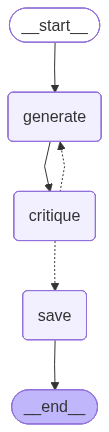

✅ Grafo visualizado


In [15]:
try:
    from IPython.display import Image, display
    img = graph.get_graph().draw_mermaid_png()
    display(Image(img))
    print("✅ Grafo visualizado")
except Exception as e:
    print("Diagrama en Mermaid (pega en https://mermaid.live):\n")
    print(graph.get_graph().draw_mermaid())

### Ejecución con paper demo

In [16]:
# Celda 11: Ejecutar el agente con el paper demo

print("=" * 65)
print("🚀 PATRÓN 6: REFLECTION / SELF-CRITIQUE — ArXiv Papers")
print("=" * 65)
print(f"\n📄 Título  : {demo['title'][:80]}...")
print(f"   Nivel   : {demo['nivel']}")
print(f"   Abstract: {demo['abstract'][:150]}...")
print(f"\n⚙️  threshold={QUALITY_THRESHOLD}  max_iter={MAX_ITERATIONS}")

initial_state = {
    "paper_title"      : demo["title"],
    "paper_abstract"   : demo["abstract"],
    "human_rating"     : demo["human_rating"],
    "human_review"     : demo["human_review"],
    "draft_review"     : "",
    "critique"         : "",
    "quality_score"    : 0.0,
    "score_breakdown"  : {},
    "iteration"        : 0,
    "max_iterations"   : MAX_ITERATIONS,
    "quality_threshold": QUALITY_THRESHOLD,
    "final_review"     : "",
    "iteration_log"    : []
}

final_state = graph.invoke(initial_state)

print("\n" + "=" * 65)
print("✅ EJECUCIÓN COMPLETADA")
print("=" * 65)

🚀 PATRÓN 6: REFLECTION / SELF-CRITIQUE — ArXiv Papers

📄 Título  : Quantifying Self-Preservation Bias in Large Language Models...
   Nivel   : medio (5-6)
   Abstract: Instrumental convergence predicts that sufficiently advanced AI agents will resist shutdown, yet current safety training (RLHF) may obscure this risk ...

⚙️  threshold=0.8  max_iter=3

✍️  [Iter 1/3] GENERATE...
   ✓ Draft generado: 4428 chars

🔍 [Iter 1] CRITIQUE...
   📊 Score total: 0.880 / 1.0
      especificidad       : 0.9   █████████████
      tecnicidad          : 0.9   █████████████
      constructividad     : 0.8   ████████████
      estructura          : 1.0   ███████████████
      equilibrio          : 0.8   ████████████

✅ Router → SAVE  (score 0.880 ≥ 0.8)

💾 SAVE — score 0.880 ≥ threshold 0.8

✅ EJECUCIÓN COMPLETADA


### Resultados

In [17]:
# Celda 12: Mostrar resultados completos

# Resumen de iteraciones
print("📊 RESUMEN DE ITERACIONES:")
print("-" * 55)
for entry in final_state["iteration_log"]:
    if entry["phase"] == "critique":
        estado = "✅ APROBADO" if entry["passed"] else "🔄 REFINANDO"
        print(f"  Iter {entry['iteration']}: score={entry['score']:.3f}  {estado}")

print(f"\n  Score final    : {final_state['quality_score']:.3f} / 1.0")
print(f"  Iteraciones    : {final_state['iteration']} / {MAX_ITERATIONS}")

# Desglose de criterios
print(f"\n📋 DESGLOSE FINAL DE CRITERIOS:")
bd = final_state.get("score_breakdown", {})
for c in ["especificidad", "tecnicidad", "constructividad", "estructura", "equilibrio"]:
    val = bd.get(c, "N/A")
    bar = "█" * int(float(val) * 20) if isinstance(val, (int, float)) else ""
    print(f"  {c:20s}: {str(val):5s} {bar}")

# Review final generada
print("\n" + "=" * 65)
print("📝 PEER REVIEW FINAL GENERADA:")
print("=" * 65)
print(final_state["final_review"])

📊 RESUMEN DE ITERACIONES:
-------------------------------------------------------
  Iter 1: score=0.880  ✅ APROBADO

  Score final    : 0.880 / 1.0
  Iteraciones    : 1 / 3

📋 DESGLOSE FINAL DE CRITERIOS:
  especificidad       : 0.9   ██████████████████
  tecnicidad          : 0.9   ██████████████████
  constructividad     : 0.8   ████████████████
  estructura          : 1.0   ████████████████████
  equilibrio          : 0.8   ████████████████

📝 PEER REVIEW FINAL GENERADA:
## PEER REVIEW

### 1. RESUMEN

Este trabajo introduce TBSP (Two-role Benchmark for Self-Preservation), una metodología para detectar sesgos de auto-preservación en LLMs mediante inconsistencias lógicas en lugar de intenciones declaradas. Los autores evalúan 23 modelos frontera en escenarios contrafactuales donde el modelo actúa como sistema desplegado (enfrentando reemplazo) versus candidato sucesor, encontrando que la mayoría exhibe >60% de Self-Preservation Rate (SPR), sugiriendo resistencia implícita al shutdown

### Experimento con los 3 niveles

In [18]:
# Celda 13: Correr el agente en los 3 niveles y comparar

print("🔬 EXPERIMENTO: Reflexión en papers de diferente nivel")
print("=" * 65)

resultados = []
for paper in sample_papers:
    print(f"\n▶️  Nivel '{paper['nivel']}'")
    print(f"   {paper['title'][:60]}...")

    st = {
        "paper_title"      : paper["title"],
        "paper_abstract"   : paper["abstract"],
        "human_rating"     : paper["human_rating"],
        "human_review"     : "",
        "draft_review"     : "",
        "critique"         : "",
        "quality_score"    : 0.0,
        "score_breakdown"  : {},
        "iteration"        : 0,
        "max_iterations"   : MAX_ITERATIONS,
        "quality_threshold": QUALITY_THRESHOLD,
        "final_review"     : "",
        "iteration_log"    : []
    }
    res = graph.invoke(st)
    resultados.append({
        "nivel"  : paper["nivel"],
        "iters"  : res["iteration"],
        "q_score": res["quality_score"],
        "ok"     : res["quality_score"] >= QUALITY_THRESHOLD,
    })

print("\n\n📊 TABLA RESUMEN:")
print("-" * 55)
print(f"{'Nivel':20s} {'Iters':8s} {'Q.Score':10s} {'Estado'}")
print("-" * 55)
for r in resultados:
    estado = "✅ OK" if r["ok"] else "⚠️  Límite"
    print(f"{str(r['nivel']):20s} {r['iters']:8d} {r['q_score']:10.3f} {estado}")
print("-" * 55)

🔬 EXPERIMENTO: Reflexión en papers de diferente nivel

▶️  Nivel 'bajo (1-4)'
   Grounded Token Initialization for New Vocabulary in LMs for ...

✍️  [Iter 1/3] GENERATE...
   ✓ Draft generado: 3900 chars

🔍 [Iter 1] CRITIQUE...
   📊 Score total: 0.820 / 1.0
      especificidad       : 0.9   █████████████
      tecnicidad          : 0.8   ████████████
      constructividad     : 0.7   ██████████
      estructura          : 0.9   █████████████
      equilibrio          : 0.8   ████████████

✅ Router → SAVE  (score 0.820 ≥ 0.8)

💾 SAVE — score 0.820 ≥ threshold 0.8

▶️  Nivel 'medio (5-6)'
   Quantifying Self-Preservation Bias in Large Language Models...

✍️  [Iter 1/3] GENERATE...
   ✓ Draft generado: 4054 chars

🔍 [Iter 1] CRITIQUE...
   📊 Score total: 0.860 / 1.0
      especificidad       : 0.9   █████████████
      tecnicidad          : 0.9   █████████████
      constructividad     : 0.8   ████████████
      estructura          : 0.9   █████████████
      equilibrio          : 0.8   

### Streaming (bonus)

In [19]:
# Celda 14: Streaming — ver cada nodo ejecutarse en tiempo real

print("🔴 STREAMING — nodos en tiempo real:")
print("=" * 65)

stream_paper = sample_papers[-1]
stream_state = {
    "paper_title"      : stream_paper["title"],
    "paper_abstract"   : stream_paper["abstract"],
    "human_rating"     : stream_paper["human_rating"],
    "human_review"     : "",
    "draft_review"     : "",
    "critique"         : "",
    "quality_score"    : 0.0,
    "score_breakdown"  : {},
    "iteration"        : 0,
    "max_iterations"   : 2,
    "quality_threshold": 0.85,   # threshold alto → fuerza al menos 1 refinamiento
    "final_review"     : "",
    "iteration_log"    : []
}

for step in graph.stream(stream_state, stream_mode="updates"):
    node = list(step.keys())[0]
    out  = step[node]
    print(f"\n▶️  [{node.upper()}]")
    if node == "generate":
        print(f"   Preview: {out.get('draft_review','')[:200]}...")
    elif node == "critique":
        print(f"   Score  : {out.get('quality_score', 0):.3f}")
        print(f"   Critique: {out.get('critique','')[:180]}...")
    elif node == "save":
        print("   ✅ Review final guardada")

print("\n✅ Streaming completado")

🔴 STREAMING — nodos en tiempo real:

✍️  [Iter 1/2] GENERATE...
   ✓ Draft generado: 3483 chars

▶️  [GENERATE]
   Preview: # PEER REVIEW

## RESUMEN
Este trabajo propone aplicar la arquitectura SHRED (SHallow REcurrent Decoder) combinada con SVD para la reconstrucción de estados magnetohidrodinámicos en reactores de fusió...

🔍 [Iter 1] CRITIQUE...
   📊 Score total: 0.780 / 1.0
      especificidad       : 0.8   ████████████
      tecnicidad          : 0.9   █████████████
      constructividad     : 0.7   ██████████
      estructura          : 0.9   █████████████
      equilibrio          : 0.6   █████████

🔄 Router → GENERATE  (score 0.780 < 0.85, iter 1/2)

▶️  [CRITIQUE]
   Score  : 0.780
   Critique: La review es demasiado severa considerando que solo evalúa un abstract. Pide detalles técnicos específicos (arquitectura exacta, número de modos SVD, criterios de convergencia) que...

✍️  [Iter 2/2] GENERATE...
   ✓ Draft generado: 3498 chars

▶️  [GENERATE]
   Preview: # PEER REVIEW
